In [5]:
import pandas as pd
df = pd.read_csv('2) Stock Prices Data Set.csv')
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [4]:
print(df.isnull().sum())


symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64


In [5]:
print(df.duplicated().sum())

0


In [6]:
df.dropna(inplace=True)

In [7]:
print(df.isnull().sum())

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 497461 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497461 non-null  str           
 1   date    497461 non-null  datetime64[us]
 2   open    497461 non-null  float64       
 3   high    497461 non-null  float64       
 4   low     497461 non-null  float64       
 5   close   497461 non-null  float64       
 6   volume  497461 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 30.4 MB


In [19]:
df.describe()

,date,open,high,low,close,volume
count,497461,497461.000000,497461.000000,497461.000000,497461.000000,4.974610e+05
mean,2016-01-06 17:16:56.524311,86.352275,87.132717,85.552616,86.368586,4.253695e+06
min,2014-01-02 00:00:00,1.620000,1.690000,1.500000,1.590000,1.010000e+02
25%,2015-01-08 00:00:00,41.690000,42.090000,41.280000,41.700000,1.080183e+06
50%,2016-01-11 00:00:00,64.970000,65.560000,64.357400,64.980000,2.085013e+06
75%,2017-01-06 00:00:00,98.410000,99.230000,97.580000,98.420000,4.271999e+06
max,2017-12-29 00:00:00,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08
std,NaN,101.471228,102.312340,100.571231,101.471516,8.232210e+06


In [28]:
pd.options.display.float_format = '{:.2f}'.format
df.mean(numeric_only=True)

open          86.35
high          87.13
low           85.55
close         86.37
volume   4253694.67
dtype: float64

In [29]:
df.median(numeric_only=True)

open          64.97
high          65.56
low           64.36
close         64.98
volume   2085013.00
dtype: float64

In [24]:
df.mode(numeric_only=True)

,open,high,low,close,volume
0,70.0,72.0,77.0,34.5,1241019


In [30]:
pd.options.display.float_format = '{:.2f}'.format
df.std(numeric_only=True)

open         101.47
high         102.31
low          100.57
close        101.47
volume   8232210.33
dtype: float64

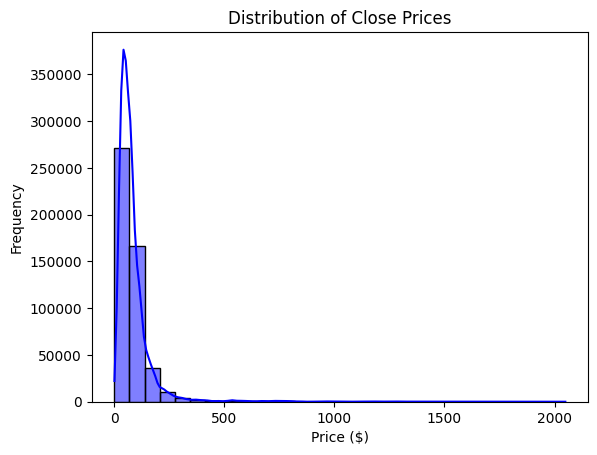

<Figure size 640x480 with 0 Axes>

In [6]:
import matplotlib.pylab as plt
import seaborn as sns
sns.histplot(df['close'], kde=True, color='blue', bins=30)
plt.title('Distribution of Close Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')       
plt.show()
plt.savefig('distribution_plot.png', dpi=300)

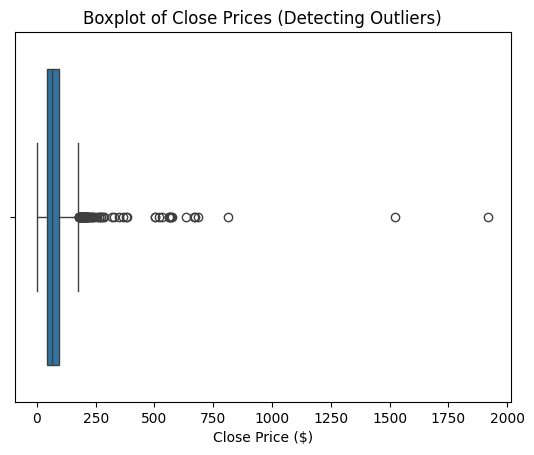

<Figure size 640x480 with 0 Axes>

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns 
df_sample = df.sample(1000)
sns.boxplot(x=df_sample ['close'])
plt.title('Boxplot of Close Prices (Detecting Outliers)')
plt.xlabel('Close Price ($)')
plt.show()
plt.savefig('outliers_boxplot.png', dpi=300)

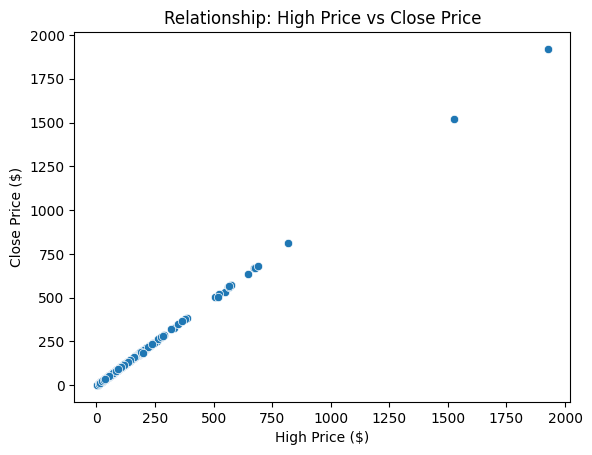

In [12]:
sns.scatterplot(x='high', y='close', data=df_sample)
plt.title('Relationship: High Price vs Close Price')
plt.xlabel('High Price ($)')
plt.ylabel('Close Price ($)')
plt.show()

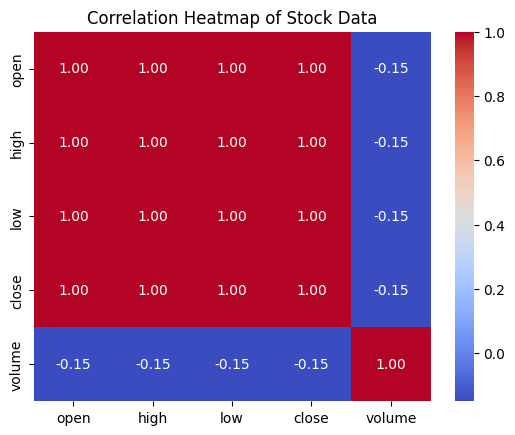

<Figure size 640x480 with 0 Axes>

In [13]:
Matrix= df.corr(numeric_only=True)
sns.heatmap(Matrix,annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Stock Data')
plt.show()
plt.savefig('correlation_heatmap.png', dpi=300)

In [8]:
df_apple = df[df['symbol']=='AAPL'].copy()
df_apple= df_apple.sort_values('date')
df_apple.set_index('date',inplace=True)
df_apple.head()


,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685


In [10]:

df_apple['Moving_Average_30']=df_apple['close'].rolling(window=30).mean()
df_apple.dropna(subset=['Moving_Average_30']).head()


,symbol,open,high,low,close,volume,Moving_Average_30
date,,,,,,,
2014-02-13,AAPL,76.3799,77.8356,76.3142,77.7756,76960156,76.127343
2014-02-14,AAPL,77.4956,77.9971,77.3156,77.7128,68468036,76.083820
2014-02-18,AAPL,77.9999,78.7413,77.9442,77.9985,65306248,76.107677
2014-02-19,AAPL,77.8214,78.1271,76.3356,76.7671,78554420,76.076440
2014-02-20,AAPL,76.1414,76.7142,75.5714,75.8785,76529103,76.034120


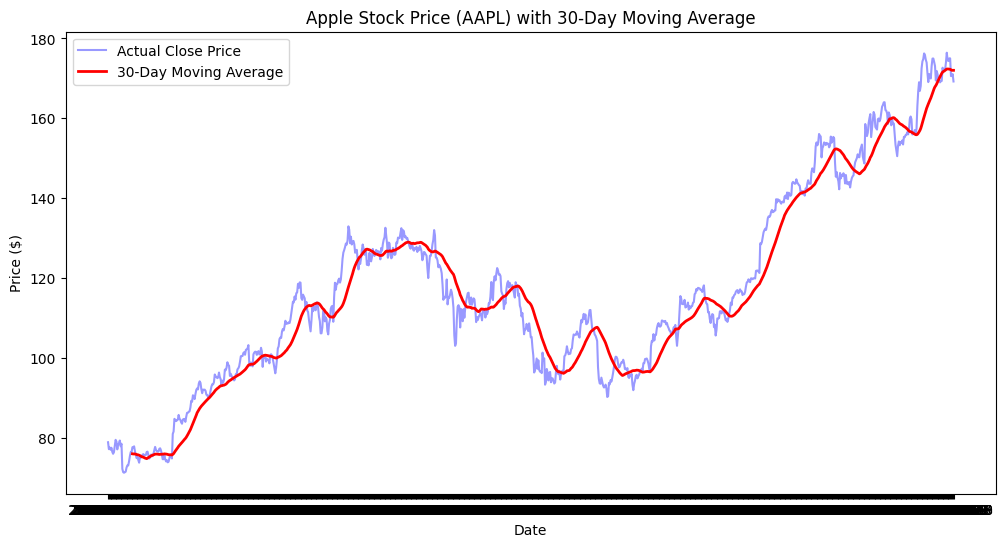

<Figure size 800x500 with 0 Axes>

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(df_apple['close'], label='Actual Close Price', color='blue', alpha=0.4)

plt.plot(df_apple['Moving_Average_30'], label='30-Day Moving Average', color='red', linewidth=2)

plt.title('Apple Stock Price (AAPL) with 30-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()
plt.savefig('apple_moving_average.png', dpi=300, bbox_inches='tight')
plt.show()

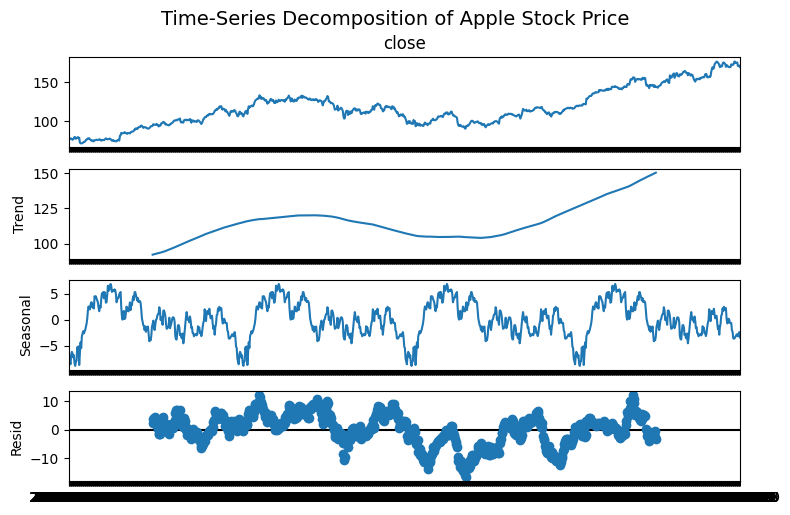

<Figure size 800x500 with 0 Axes>

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df_apple['close'], model='additive', period=252)

plt.rcParams['figure.figsize'] = (8, 5)
result.plot()

plt.suptitle('Time-Series Decomposition of Apple Stock Price', y=1.02, fontsize=14)
plt.show()
plt.savefig('apple_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = df_apple[['open']]
y = df_apple['close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 805
Testing samples: 202


In [17]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Slope (Coefficient): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

Slope (Coefficient): 0.9985
Intercept: 0.2057
R-squared (R2 Score): 0.9968
Mean Squared Error (MSE): 1.8421


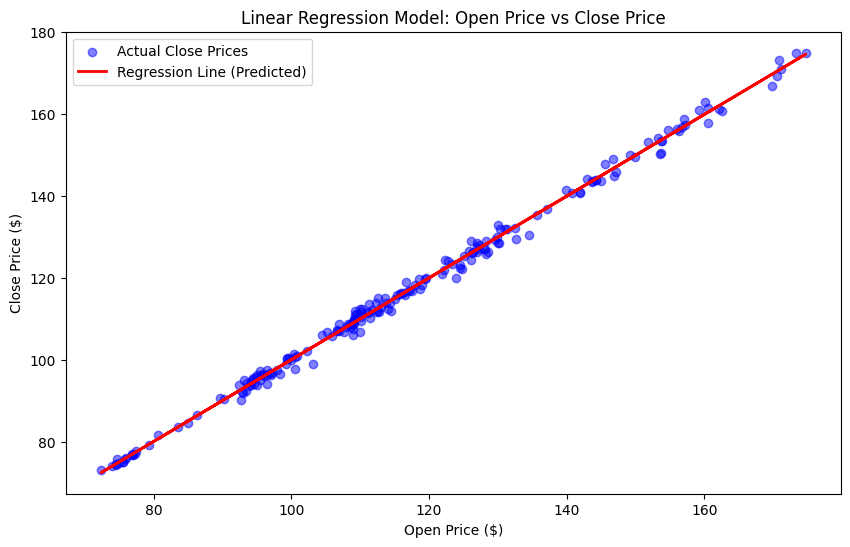

<Figure size 800x500 with 0 Axes>

In [21]:
plt.figure(figsize=(10, 6))

plt.scatter(X_test[:300], y_test[:300], color='blue', alpha=0.5, label='Actual Close Prices')

plt.plot(X_test[:300], y_pred[:300], color='red', linewidth=2, label='Regression Line (Predicted)')

plt.title('Linear Regression Model: Open Price vs Close Price')
plt.xlabel('Open Price ($)')
plt.ylabel('Close Price ($)')
plt.legend()
plt.show()
plt.savefig('apple_regression_line.png', dpi=300, bbox_inches='tight')
plt.show()